In [1]:
# Check Python version
!python --version

Python 3.13.15


In [2]:
# Import basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [6]:
import os

print(os.listdir('/content'))

['.config', 'archive.zip', 'sample_data']


In [7]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
print(os.listdir('/content/dataset'))

['NEU-DET']


In [9]:
import os

dataset_path = '/content/dataset/NEU-DET'

print(os.listdir(dataset_path))

['validation', 'train']


In [10]:
for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "files")

/content/dataset/NEU-DET -> 0 files
/content/dataset/NEU-DET/validation -> 0 files
/content/dataset/NEU-DET/validation/annotations -> 361 files
/content/dataset/NEU-DET/validation/images -> 0 files
/content/dataset/NEU-DET/validation/images/rolled-in_scale -> 60 files
/content/dataset/NEU-DET/validation/images/inclusion -> 60 files
/content/dataset/NEU-DET/validation/images/pitted_surface -> 60 files
/content/dataset/NEU-DET/validation/images/patches -> 60 files
/content/dataset/NEU-DET/validation/images/crazing -> 60 files
/content/dataset/NEU-DET/validation/images/scratches -> 60 files
/content/dataset/NEU-DET/train -> 0 files
/content/dataset/NEU-DET/train/annotations -> 1439 files
/content/dataset/NEU-DET/train/images -> 0 files
/content/dataset/NEU-DET/train/images/rolled-in_scale -> 240 files
/content/dataset/NEU-DET/train/images/inclusion -> 240 files
/content/dataset/NEU-DET/train/images/pitted_surface -> 240 files
/content/dataset/NEU-DET/train/images/patches -> 240 files
/con

In [11]:
import matplotlib.pyplot as plt
import os
from PIL import Image

train_path = '/content/dataset/NEU-DET/train/images'

classes = os.listdir(train_path)

print("Classes:")
print(classes)

Classes:
['rolled-in_scale', 'inclusion', 'pitted_surface', 'patches', 'crazing', 'scratches']


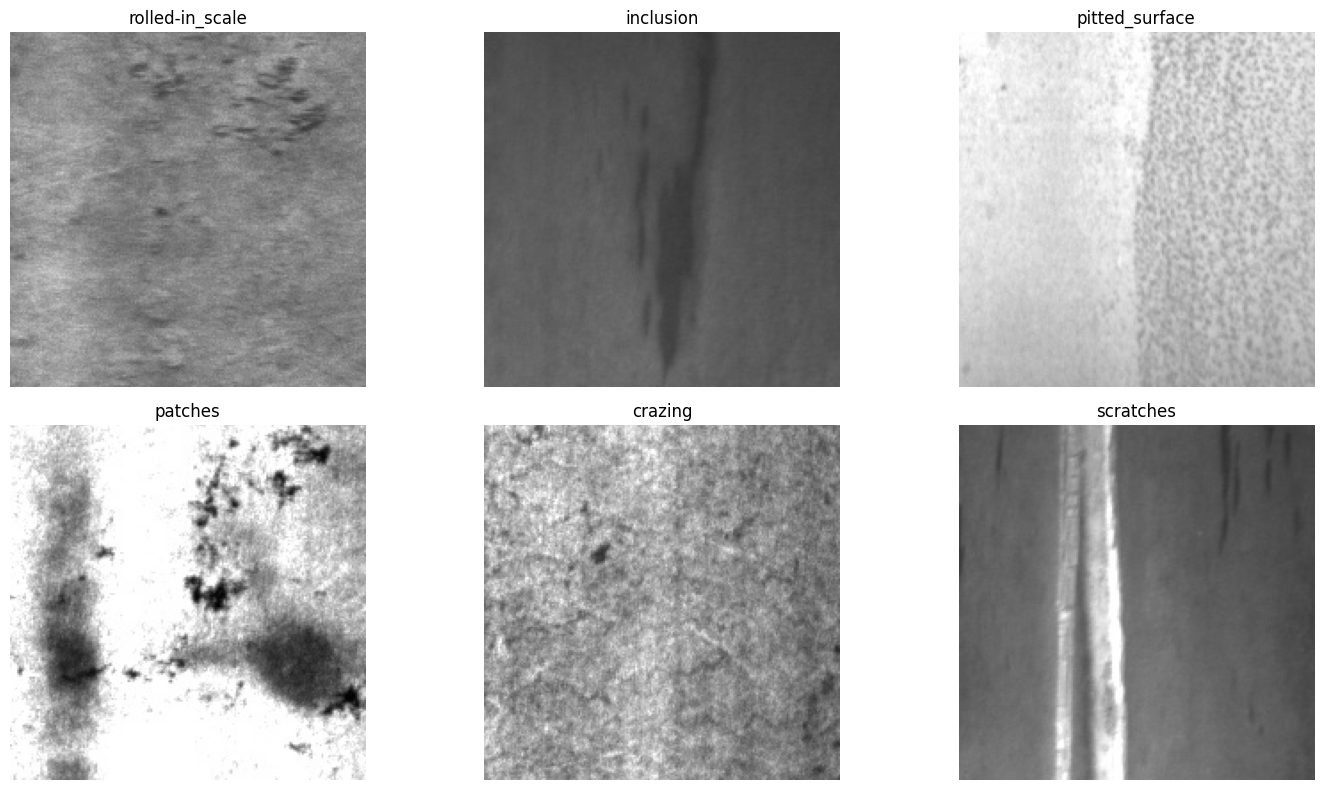

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
sample_class = classes[0]
sample_image = os.listdir(os.path.join(train_path, sample_class))[0]

image_path = os.path.join(train_path, sample_class, sample_image)

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (200, 200)
Image mode: RGB


In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [15]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_path = '/content/dataset/NEU-DET/train/images'
validation_path = '/content/dataset/NEU-DET/validation/images'

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 128
Batch size: 32


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 1440 images belonging to 6 classes.


In [17]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_data = validation_datagen.flow_from_directory(
    validation_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 360 images belonging to 6 classes.


In [18]:
print(train_data.class_indices)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [19]:
images, labels = next(train_data)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 1)
Label batch shape: (32, 6)


In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input + First Convolution
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Six defect classes
    layers.Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,838 (12.61 MB)

 Trainable params: 3,304,838 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [22]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=15
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 701ms/step - accuracy: 0.2646 - loss: 1.6675 - val_accuracy: 0.4000 - val_loss: 1.5862
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 672ms/step - accuracy: 0.5375 - loss: 1.1888 - val_accuracy: 0.5583 - val_loss: 1.4663
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 699ms/step - accuracy: 0.7319 - loss: 0.7670 - val_accuracy: 0.6083 - val_loss: 1.3773
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 683ms/step - accuracy: 0.8076 - loss: 0.5953 - val_accuracy: 0.7083 - val_loss: 0.7314
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 675ms/step - accuracy: 0.8215 - loss: 0.5505 - val_accuracy: 0.6639 - val_loss: 0.9678
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 688ms/step - accuracy: 0.8660 - loss: 0.4366 - val_accuracy: 0.5944 - val_loss: 1.3109
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 675ms/step - accuracy: 0.8771 - loss: 0.4113 - val_accuracy: 0.6139 - val_loss: 1.8566
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 703ms/step - accuracy: 0.9021 - loss: 0.3410 - val_accu

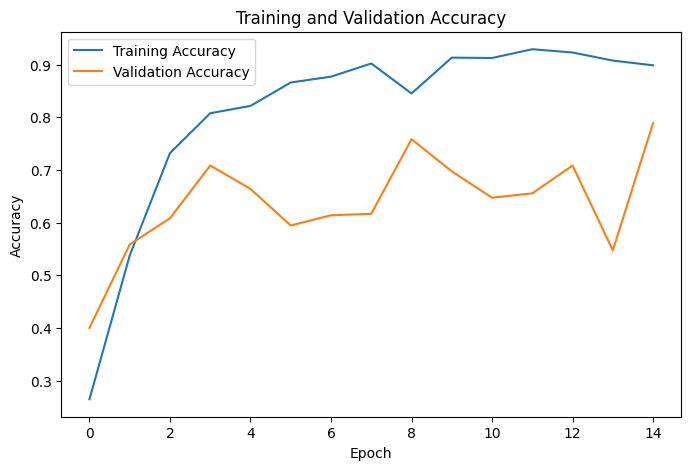

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

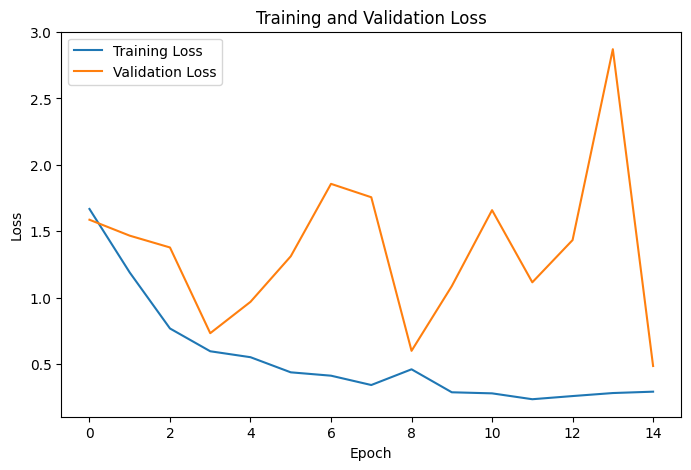

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [25]:
# Evaluate the model on validation data

validation_loss, validation_accuracy = model.evaluate(validation_data)

print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.7889 - loss: 0.4841
Validation Loss: 0.4841061532497406
Validation Accuracy: 0.7888888716697693


In [26]:
print("Validation Accuracy: {:.2f}%".format(validation_accuracy * 100))

Validation Accuracy: 78.89%


In [27]:
import numpy as np

# Reset validation generator
validation_data.reset()

predictions = model.predict(validation_data)

# Convert probability outputs into class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Actual class numbers
true_classes = validation_data.classes

print("Predictions generated successfully!")
print("Number of predictions:", len(predicted_classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step
Predictions generated successfully!
Number of predictions: 360


In [28]:
import numpy as np

# Reset validation generator
validation_data.reset()

predictions = model.predict(validation_data)

# Convert probability outputs into class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Actual class numbers
true_classes = validation_data.classes

print("Predictions generated successfully!")
print("Number of predictions:", len(predicted_classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step
Predictions generated successfully!
Number of predictions: 360


In [29]:
class_names = list(validation_data.class_indices.keys())

print("Class names:")
print(class_names)

Class names:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


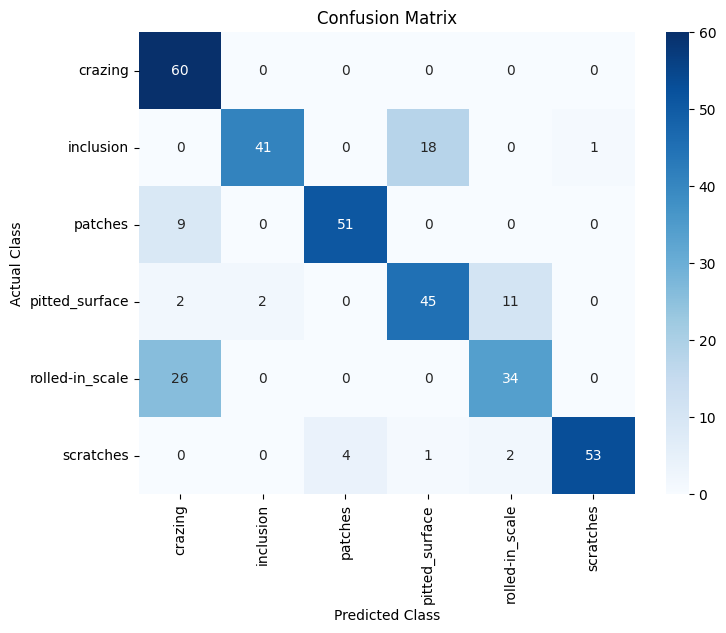

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

print(report)

                 precision    recall  f1-score   support

        crazing       0.62      1.00      0.76        60
      inclusion       0.95      0.68      0.80        60
        patches       0.93      0.85      0.89        60
 pitted_surface       0.70      0.75      0.73        60
rolled-in_scale       0.72      0.57      0.64        60
      scratches       0.98      0.88      0.93        60

       accuracy                           0.79       360
      macro avg       0.82      0.79      0.79       360
   weighted avg       0.82      0.79      0.79       360



In [32]:
with open('/content/classification_report.txt', 'w') as file:
    file.write(report)

print("Classification report saved!")

Classification report saved!


In [33]:
from google.colab import files

files.download('/content/classification_report.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import os

validation_path = '/content/dataset/NEU-DET/validation/images'

# Get the first class
selected_class = os.listdir(validation_path)[0]

# Get the first image in that class
class_path = os.path.join(validation_path, selected_class)
selected_image = os.listdir(class_path)[0]

image_path = os.path.join(class_path, selected_image)

print("Actual class:", selected_class)
print("Image:", selected_image)
print("Path:", image_path)

Actual class: rolled-in_scale
Image: rolled-in_scale_279.jpg
Path: /content/dataset/NEU-DET/validation/images/rolled-in_scale/rolled-in_scale_279.jpg


Image size: (200, 200)


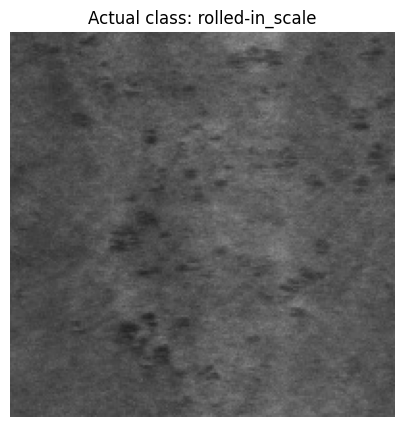

In [37]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)

print("Image size:", image.size)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title(f"Actual class: {selected_class}")
plt.axis('off')
plt.show()

In [38]:
import os
import random

validation_path = '/content/dataset/NEU-DET/validation/images'

# Get all classes
classes = os.listdir(validation_path)

# Select a random class
selected_class = random.choice(classes)

# Get images from that class
class_path = os.path.join(validation_path, selected_class)
image_files = os.listdir(class_path)

# Select one random image
selected_image = random.choice(image_files)

image_path = os.path.join(class_path, selected_image)

print("Actual class:", selected_class)
print("Image:", selected_image)
print("Image path:", image_path)

Actual class: rolled-in_scale
Image: rolled-in_scale_252.jpg
Image path: /content/dataset/NEU-DET/validation/images/rolled-in_scale/rolled-in_scale_252.jpg


In [39]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Open image
image = Image.open(image_path).convert('L')

# Resize
image_resized = image.resize((IMG_SIZE, IMG_SIZE))

# Convert to array
image_array = np.array(image_resized) / 255.0

# Add batch and channel dimensions
image_input = np.expand_dims(image_array, axis=0)
image_input = np.expand_dims(image_input, axis=-1)

# Prediction
prediction = model.predict(image_input, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Actual class     :", selected_class)
print("Predicted class  :", predicted_class)
print("Confidence       : {:.2f}%".format(confidence))

Actual class     : rolled-in_scale
Predicted class  : rolled-in_scale
Confidence       : 96.35%


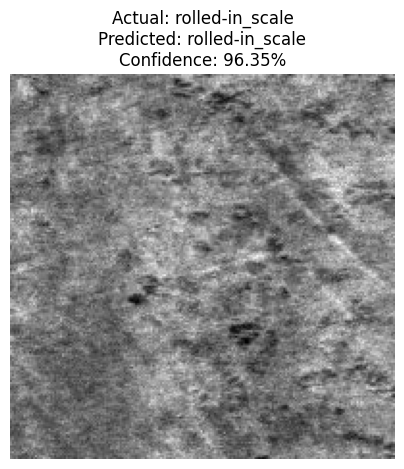

In [40]:
plt.figure(figsize=(5, 5))

plt.imshow(image, cmap='gray')
plt.title(
    f"Actual: {selected_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis('off')
plt.show()

In [41]:
import os

validation_path = '/content/dataset/NEU-DET/validation/images'

selected_class = os.listdir(validation_path)[0]
class_path = os.path.join(validation_path, selected_class)

selected_image = os.listdir(class_path)[0]
image_path = os.path.join(class_path, selected_image)

print("Actual class:", selected_class)
print("Image:", selected_image)
print("Path:", image_path)

Actual class: rolled-in_scale
Image: rolled-in_scale_279.jpg
Path: /content/dataset/NEU-DET/validation/images/rolled-in_scale/rolled-in_scale_279.jpg


Image size: (200, 200)


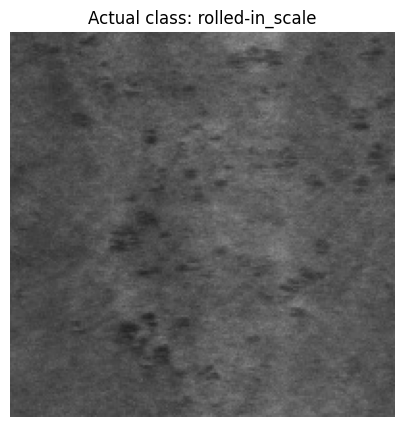

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)

print("Image size:", image.size)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title(f"Actual class: {selected_class}")
plt.axis('off')
plt.show()

In [43]:
from PIL import Image
import numpy as np

# Load image
image = Image.open(image_path).convert('L')

# Resize to the same size used during training
image_resized = image.resize((IMG_SIZE, IMG_SIZE))

# Convert image to array and normalize
image_array = np.array(image_resized) / 255.0

# Add batch dimension and channel dimension
image_input = np.expand_dims(image_array, axis=0)
image_input = np.expand_dims(image_input, axis=-1)

# Make prediction
prediction = model.predict(image_input, verbose=0)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]

# Get confidence
confidence = prediction[0][predicted_index] * 100

print("Actual class:", selected_class)
print("Predicted class:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

Actual class: rolled-in_scale
Predicted class: rolled-in_scale
Confidence: 98.49%


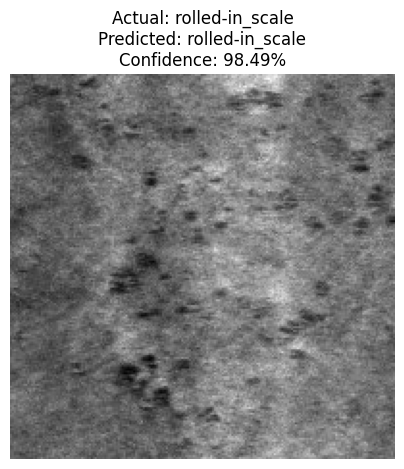

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')

plt.title(
    f"Actual: {selected_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis('off')
plt.show()

In [45]:
for class_name, probability in zip(class_names, prediction[0]):
    print(f"{class_name}: {probability * 100:.2f}%")

crazing: 0.10%
inclusion: 0.05%
patches: 0.01%
pitted_surface: 1.21%
rolled-in_scale: 98.49%
scratches: 0.14%


In [46]:
model.save('/content/baseline_surface_defect_cnn.keras')

print("Baseline CNN model saved successfully!")

Baseline CNN model saved successfully!


In [47]:
with open('/content/classification_report.txt', 'w') as file:
    file.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!


In [48]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
)

with open('/content/classification_report.txt', 'w') as file:
    file.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!


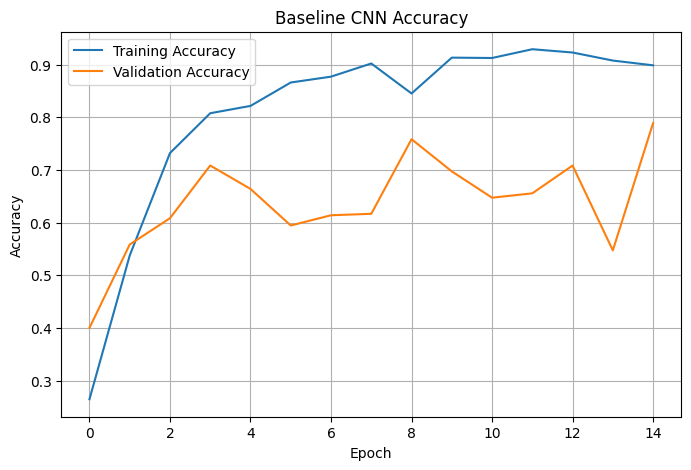

Accuracy graph saved!


In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Accuracy')
plt.legend()
plt.grid()

plt.savefig('/content/baseline_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Accuracy graph saved!")

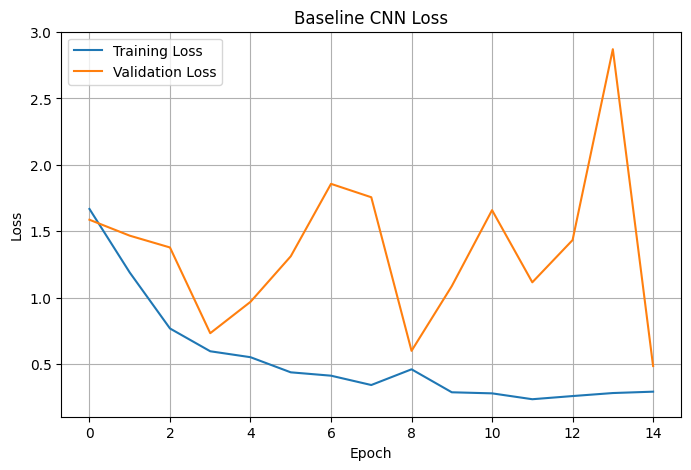

Loss graph saved!


In [50]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline CNN Loss')
plt.legend()
plt.grid()

plt.savefig('/content/baseline_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("Loss graph saved!")

In [51]:
from tensorflow.keras import layers, models

improved_model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

improved_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,430 (1.62 MB)

 Trainable params: 422,470 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [52]:
improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [53]:
improved_history = improved_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=15
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7347 - loss: 0.7630 - val_accuracy: 0.1861 - val_loss: 2.6356
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8403 - loss: 0.4668 - val_accuracy: 0.2222 - val_loss: 3.1521
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8660 - loss: 0.3784 - val_accuracy: 0.1667 - val_loss: 4.3590
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9028 - loss: 0.2802 - val_accuracy: 0.2361 - val_loss: 5.3989
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9236 - loss: 0.2307 - val_accuracy: 0.1917 - val_loss: 5.6320
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9278 - loss: 0.2005 - val_accuracy: 0.1667 - val_loss: 6.5955
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9333 - loss: 0.1985 - val_accuracy: 0.1778 - val_loss: 6.6083
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9375 - loss: 0.1766 - val_accuracy: 0.2583 - val_loss:

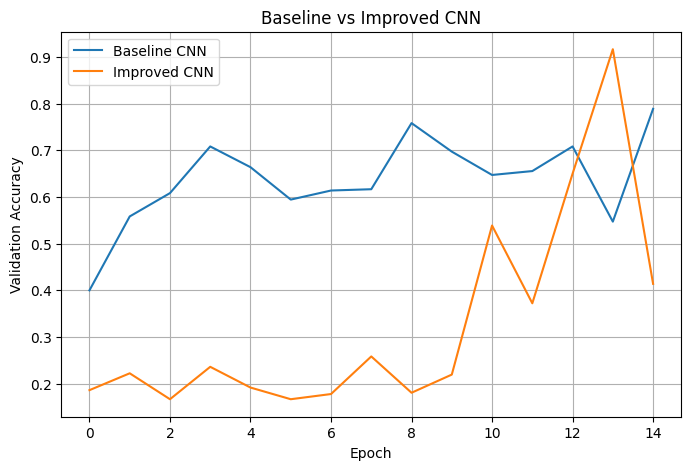

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['val_accuracy'],
    label='Baseline CNN'
)

plt.plot(
    improved_history.history['val_accuracy'],
    label='Improved CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Improved CNN')
plt.legend()
plt.grid()

plt.show()

In [55]:
improved_loss, improved_accuracy = improved_model.evaluate(
    validation_data
)

print("Improved Model Validation Loss:", improved_loss)
print("Improved Model Validation Accuracy:", improved_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.4139 - loss: 5.0473
Improved Model Validation Loss: 5.0472588539123535
Improved Model Validation Accuracy: 0.4138889014720917


In [56]:
validation_data.reset()

improved_predictions = improved_model.predict(
    validation_data,
    verbose=1
)

improved_predicted_classes = np.argmax(
    improved_predictions,
    axis=1
)

true_classes = validation_data.classes

print("Predictions generated successfully!")

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 355ms/step
Predictions generated successfully!


In [57]:
from sklearn.metrics import classification_report

improved_report = classification_report(
    true_classes,
    improved_predicted_classes,
    target_names=class_names
)

print(improved_report)

                 precision    recall  f1-score   support

        crazing       0.56      1.00      0.71        60
      inclusion       0.85      0.18      0.30        60
        patches       1.00      0.13      0.24        60
 pitted_surface       0.67      0.03      0.06        60
rolled-in_scale       0.27      1.00      0.43        60
      scratches       1.00      0.13      0.24        60

       accuracy                           0.41       360
      macro avg       0.72      0.41      0.33       360
   weighted avg       0.72      0.41      0.33       360



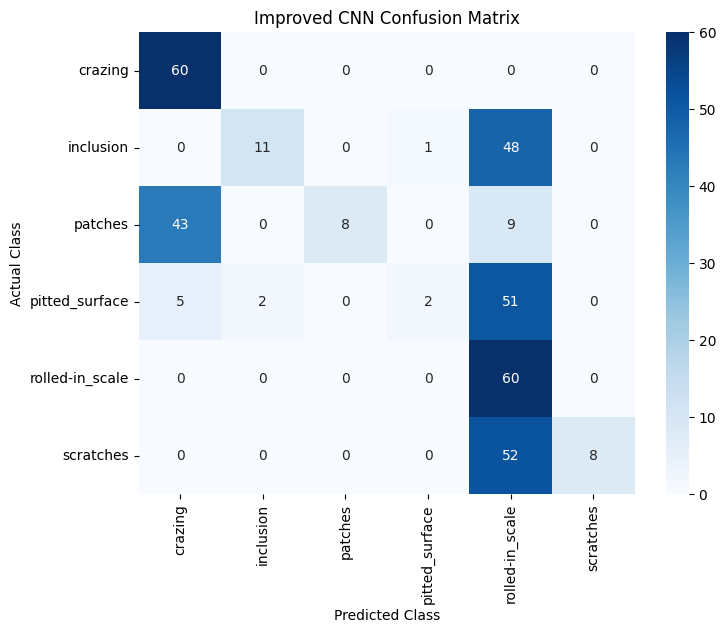

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

improved_cm = confusion_matrix(
    true_classes,
    improved_predicted_classes
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    improved_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Improved CNN Confusion Matrix')

plt.savefig(
    '/content/improved_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

baseline_accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

improved_accuracy_score = accuracy_score(
    true_classes,
    improved_predicted_classes
)

baseline_precision = precision_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

improved_precision = precision_score(
    true_classes,
    improved_predicted_classes,
    average='weighted'
)

baseline_recall = recall_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

improved_recall = recall_score(
    true_classes,
    improved_predicted_classes,
    average='weighted'
)

baseline_f1 = f1_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

improved_f1 = f1_score(
    true_classes,
    improved_predicted_classes,
    average='weighted'
)

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Baseline CNN': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    'Improved CNN': [
        improved_accuracy_score,
        improved_precision,
        improved_recall,
        improved_f1
    ]
})

comparison

,Metric,Baseline CNN,Improved CNN
0,Accuracy,0.788889,0.413889
1,Precision,0.817888,0.723517
2,Recall,0.788889,0.413889
3,F1-Score,0.789758,0.329718


In [60]:
accuracy_improvement = (
    improved_accuracy_score - baseline_accuracy
) * 100

print(
    "Accuracy change:",
    round(accuracy_improvement, 2),
    "percentage points"
)

Accuracy change: -37.5 percentage points


In [61]:
improved_model.save(
    '/content/improved_surface_defect_cnn.keras'
)

print("Improved model saved successfully!")

Improved model saved successfully!


In [62]:
comparison.to_csv(
    '/content/model_comparison.csv',
    index=False
)

print("Model comparison saved!")

Model comparison saved!


In [63]:
with open(
    '/content/improved_classification_report.txt',
    'w'
) as file:
    file.write(improved_report)

print("Improved classification report saved!")

Improved classification report saved!
